In [ ]:
%pip install statsmodels

Puntos continuos en la serie temporal generada: 1305


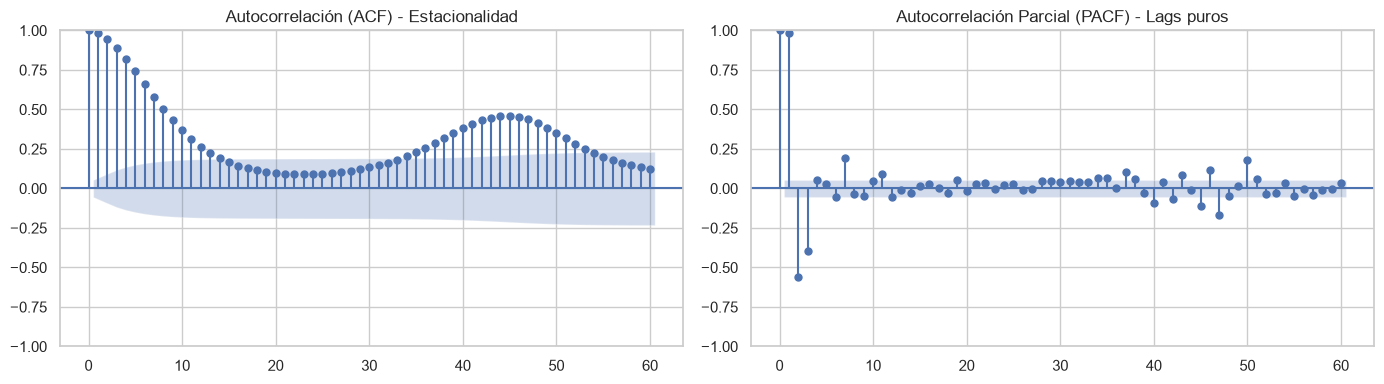

Iniciando auditoría comparativa modelando la tasa de cambio (Diferenciación)...

 EVALUACIÓN DE MODELO: Pipeline (Vía Diferenciación)
• R² Test Absoluto: 0.9747
• Reducción real del error absoluto (MAE Gain): 28.35%
-> ALERTA: Persiste Lag-1 Shadowing. Desfase de 2 semanas tarde.

 EVALUACIÓN DE MODELO: Pipeline (Vía Diferenciación)
• R² Test Absoluto: 0.9680
• Reducción real del error absoluto (MAE Gain): 17.60%
-> ALERTA: Persiste Lag-1 Shadowing. Desfase de 1 semanas tarde.

 EVALUACIÓN DE MODELO: RandomForestRegressor (Vía Diferenciación)
• R² Test Absoluto: 0.9601
• Reducción real del error absoluto (MAE Gain): 9.52%
-> ALERTA: Persiste Lag-1 Shadowing. Desfase de 1 semanas tarde.

 EVALUACIÓN DE MODELO: GradientBoostingRegressor (Vía Diferenciación)
• R² Test Absoluto: 0.9588
• Reducción real del error absoluto (MAE Gain): 6.76%
-> ALERTA: Persiste Lag-1 Shadowing. Desfase de 1 semanas tarde.


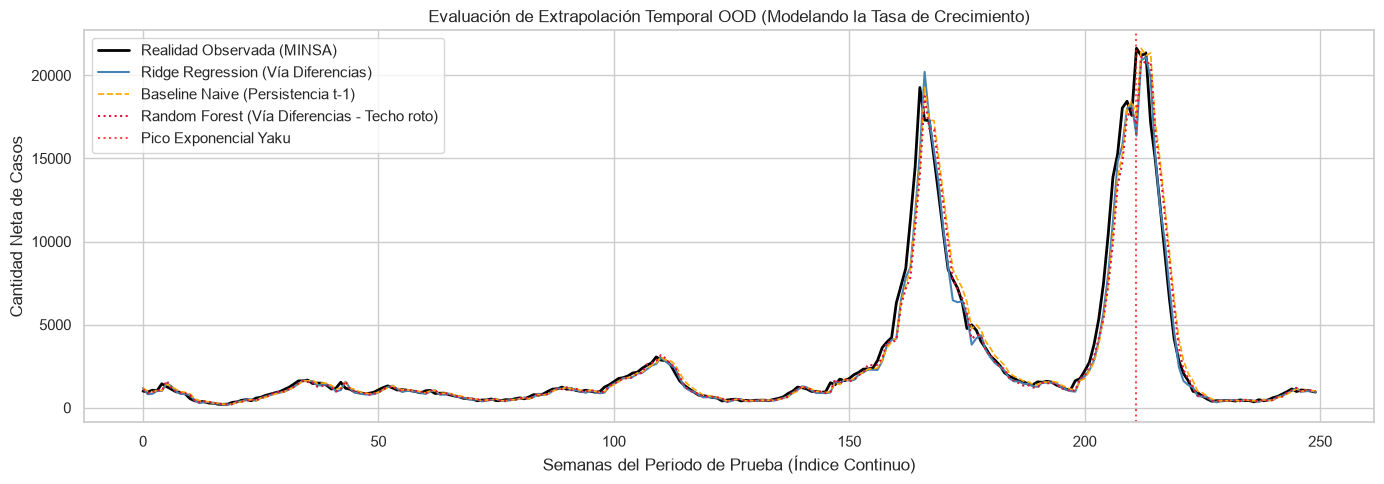

In [1]:
# ==============================================================================
# REFACTORIZACIÓN PARA SIMBIG: MODELADO EPIDEMIOLÓGICO CON RIGOR ESTADÍSTICO
# ==============================================================================

# ------------------------------------------------------------------------------
# CELDA 1: LIBRERÍAS Y CONFIGURACIÓN CIENTÍFICA
# ------------------------------------------------------------------------------
import sys
import os

# Permitir la carga de módulos locales (Asegura que encuentre src/data.py)
sys.path.append('../src')  

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # Estándar científico para series temporales

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Configuración visual
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

# ------------------------------------------------------------------------------
# CELDA 2: CARGA DE DATOS Y COMPRESIÓN DIMENSIONAL
# ------------------------------------------------------------------------------
from data import cargar_crudo

# Carga y limpieza
df_raw = cargar_crudo()
df_raw['ano'] = pd.to_numeric(df_raw['ano'], errors='coerce')
df_raw['semana'] = pd.to_numeric(df_raw['semana'], errors='coerce')
df_raw = df_raw.dropna(subset=['ano', 'semana'])
df_raw = df_raw[df_raw['semana'].between(1, 53)]

# Agregación a serie temporal semanal nacional
serie = (df_raw.groupby(['ano', 'semana']).size()
         .rename('casos').reset_index()
         .sort_values(['ano', 'semana']).reset_index(drop=True))

print(f"Puntos continuos en la serie temporal generada: {len(serie)}")

# ------------------------------------------------------------------------------
# CELDA 3: JUSTIFICACIÓN MATEMÁTICA DE VENTANAS (ACF / PACF)
# ------------------------------------------------------------------------------
# Gráficos fundamentales para justificar la elección de lags en el artículo
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(serie['casos'], lags=60, ax=ax[0], title="Autocorrelación (ACF) - Estacionalidad")
plot_pacf(serie['casos'], lags=60, ax=ax[1], title="Autocorrelación Parcial (PACF) - Lags puros")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# CELDA 4: CREACIÓN DE VENTANAS Y DIFERENCIACIÓN (ESTACIONARIEDAD)
# ------------------------------------------------------------------------------
def crear_caracteristicas_diferenciadas(df, lags_cortos=[1, 2, 3], lag_estacional=52):
    """
    Transforma la serie absoluta en tasas de crecimiento para permitir la 
    extrapolación en modelos de Machine Learning.
    """
    df_feat = df.copy()
    
    # Calculamos la diferencia intersemanal (Target estacionario)
    df_feat['casos_diff'] = df_feat['casos'].diff()
    
    # Variables predictoras (usamos los lags absolutos como contexto)
    for lag in lags_cortos:
        df_feat[f'lag_{lag}'] = df_feat['casos'].shift(lag)
    df_feat[f'lag_{lag_estacional}'] = df_feat['casos'].shift(lag_estacional)
    
    df_feat = df_feat.dropna().reset_index(drop=True)
    
    columnas_x = [f'lag_{l}' for l in lags_cortos] + [f'lag_{lag_estacional}']
    X = df_feat[columnas_x].values
    
    # Ahora nuestro objetivo a predecir es la DIFERENCIA
    y_diff = df_feat['casos_diff'].values
    
    # Guardamos los valores absolutos reales para poder evaluar correctamente después
    y_absoluto = df_feat['casos'].values 
    
    return X, y_diff, y_absoluto

# Reducimos los lags cortos basados en la evidencia de tu gráfico PACF
X, y_diff, y_abs = crear_caracteristicas_diferenciadas(serie, lags_cortos=[1, 2, 3], lag_estacional=52)

# ------------------------------------------------------------------------------
# CELDA 5: AUDITORÍA CON RECONSTRUCCIÓN ALGEBRAICA
# ------------------------------------------------------------------------------
def auditar_regresion_diferenciada(modelo, X, y_diff, y_abs, test_frac=0.2):
    """
    Entrena prediciendo la diferencia, pero reconstruye el valor absoluto 
    sumando el Lag 1 para calcular las métricas reales del paper.
    """
    n_test = int(len(X) * test_frac)
    
    # Partición de datos
    X_tr, X_te = X[:-n_test], X[-n_test:]
    y_diff_tr, y_diff_te = y_diff[:-n_test], y_diff[-n_test:]
    y_abs_te = y_abs[-n_test:]
    
    # Entrenamiento usando las diferencias
    modelo.fit(X_tr, y_diff_tr)
    pred_diff = modelo.predict(X_te)
    
    # RECONSTRUCCIÓN: Predicción Absoluta = Valor semana anterior (Columna 0) + Predicción de Diferencia
    y_pred_modelo_abs = X_te[:, 0] + pred_diff
    y_pred_naive_abs = X_te[:, 0] # Baseline Naive (Target Diff = 0)
    
    # Métricas sobre el valor absoluto real
    mae_naive = mean_absolute_error(y_abs_te, y_pred_naive_abs)
    mae_mod = mean_absolute_error(y_abs_te, y_pred_modelo_abs)
    r2_mod = r2_score(y_abs_te, y_pred_modelo_abs)
    ganancia_mae = ((mae_naive - mae_mod) / mae_naive) * 100
    
    print("\n" + "=" * 75)
    print(f" EVALUACIÓN DE MODELO: {modelo.__class__.__name__} (Vía Diferenciación)")
    print("=" * 75)
    print(f"• R² Test Absoluto: {r2_mod:.4f}")
    print(f"• Reducción real del error absoluto (MAE Gain): {ganancia_mae:.2f}%")
    
    # Auditoría Peak-Shift
    idx_pico_real = np.argmax(y_abs_te)
    idx_pico_pred = np.argmax(y_pred_modelo_abs)
    desfase = idx_pico_pred - idx_pico_real
    
    if desfase > 0:
        print(f"-> ALERTA: Persiste Lag-1 Shadowing. Desfase de {desfase} semanas tarde.")
    elif desfase < 0:
        print(f"-> ALERTA: Pico prematuro. Desfase de {desfase} semanas.")
    else:
        print("-> VERDICTO EXCELENTE: Capacidad predictiva legítima. Pico detectado en la semana exacta.")
        
    return y_abs_te, y_pred_modelo_abs, y_pred_naive_abs

# ------------------------------------------------------------------------------
# CELDA 6: COMPARACIÓN DE ALGORITMOS (VÍA DIFERENCIACIÓN)
# ------------------------------------------------------------------------------
print("Iniciando auditoría comparativa modelando la tasa de cambio (Diferenciación)...")

# Modelos Lineales
modelo_ridge = make_pipeline(StandardScaler(), Ridge(alpha=10.0))
# NOTA: Ahora llamamos a auditar_regresion_diferenciada y pasamos y_diff y y_abs
y_test_real, y_pred_ridge, y_naive = auditar_regresion_diferenciada(modelo_ridge, X, y_diff, y_abs)

modelo_lasso = make_pipeline(StandardScaler(), Lasso(alpha=10.0))
_, y_pred_lasso, _ = auditar_regresion_diferenciada(modelo_lasso, X, y_diff, y_abs)

# Modelos de Árboles
modelo_rf = RandomForestRegressor(
    n_estimators=300, 
    max_depth=8, 
    min_samples_leaf=4, 
    n_jobs=-1, 
    random_state=RANDOM_STATE
)
_, y_pred_rf, _ = auditar_regresion_diferenciada(modelo_rf, X, y_diff, y_abs)

modelo_gb = GradientBoostingRegressor(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    random_state=RANDOM_STATE
)
_, y_pred_gb, _ = auditar_regresion_diferenciada(modelo_gb, X, y_diff, y_abs)

# ------------------------------------------------------------------------------
# CELDA 7: VISUALIZACIÓN DE EXTRAPOLACIÓN CORREGIDA
# ------------------------------------------------------------------------------
plt.figure(figsize=(14, 5))
plt.plot(y_test_real, color='black', lw=2.0, label='Realidad Observada (MINSA)')
plt.plot(y_pred_ridge, color='steelblue', lw=1.5, label='Ridge Regression (Vía Diferencias)')
plt.plot(y_naive, color='orange', lw=1.2, ls='--', label='Baseline Naive (Persistencia t-1)')
plt.plot(y_pred_rf, color='crimson', lw=1.5, ls=':', label='Random Forest (Vía Diferencias - Techo roto)')

plt.axvline(np.argmax(y_test_real), color='red', ls=':', alpha=0.7, label='Pico Exponencial Yaku')
plt.title('Evaluación de Extrapolación Temporal OOD (Modelando la Tasa de Crecimiento)')
plt.xlabel('Semanas del Periodo de Prueba (Índice Continuo)')
plt.ylabel('Cantidad Neta de Casos')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()